In [4]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.layers import (Dense, Flatten, Reshape, Convolution2D, MaxPooling2D, Rescaling, Dropout,
                                     RandomRotation, RandomFlip)

from keras.datasets import fashion_mnist

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [5]:
BACK_C = (.12, .12, .12, 1.)
plt.style.use('dark_background')


In [6]:
params = {'figure.facecolor': BACK_C,
          'axes.facecolor': BACK_C,
          'axes.titleweight': 'bold'}

plt.rcParams.update(params)


In [10]:
def get_preprocessing(shape: tuple) -> keras.Sequential:
    preprocessor = keras.Sequential([
        Reshape(shape),
        Rescaling(1./255),

        RandomFlip(),
        RandomRotation(.10),
    ])

    return preprocessor

def get_model(n_class: int, activation: str = 'relu') -> keras.Sequential:

    preprocessor = get_preprocessing((28, 28, 1))

    model = keras.Sequential([
        preprocessor,

        Convolution2D(32, 3, activation=activation),
        MaxPooling2D(2),

        Convolution2D(64, 3, activation=activation),
        MaxPooling2D(2),

        Flatten(),

        Dense(units=128, activation=activation),
        Dense(units=128, activation=activation),
        Dropout(.3),

        Dense(units=n_class, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


def plot_lc(history: dict, metrics: list = ['loss', 'accuracy']) -> None:
    plt.figure(figsize=(20, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.title(f'Learning curve for {metric}\n')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.xlabel('epochs')
        plt.ylabel(metric)
        plt.legend()
    plt.show()


def plot_cm(y_true: np.array, y_pred: np.array) -> None:
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(20, 8))
    plt.title('Confusion Matrix\n')
    sns.heatmap(cm, cmap='vlag', annot=True, fmt='d', cbar=False)
    plt.xlabel('y_pred')
    plt.ylabel('y_true')
    plt.show()


In [11]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(X_train.shape)
print(y_train.shape)


(60000, 28, 28)
(60000,)


In [14]:
cnn = get_model(10)
cnn.fit(X_train, y_train, validation_split=.2, epochs=100, batch_size=1024)

Epoch 1/100
47/47 [==============================] - 1s 11ms/step - loss: 1.6128 - accuracy: 0.3926 - val_loss: 0.9926 - val_accuracy: 0.6271
Epoch 2/100
47/47 [==============================] - 0s 10ms/step - loss: 1.0252 - accuracy: 0.6146 - val_loss: 0.8061 - val_accuracy: 0.6964
Epoch 3/100
47/47 [==============================] - 0s 10ms/step - loss: 0.8512 - accuracy: 0.6786 - val_loss: 0.7353 - val_accuracy: 0.7179
Epoch 4/100
47/47 [==============================] - 0s 10ms/step - loss: 0.7776 - accuracy: 0.7048 - val_loss: 0.6862 - val_accuracy: 0.7321
Epoch 5/100
47/47 [==============================] - 0s 9ms/step - loss: 0.7246 - accuracy: 0.7235 - val_loss: 0.6283 - val_accuracy: 0.7526
Epoch 6/100
47/47 [==============================] - 0s 9ms/step - loss: 0.6963 - accuracy: 0.7363 - val_loss: 0.6176 - val_accuracy: 0.7573
Epoch 7/100
47/47 [==============================] - 0s 9ms/step - loss: 0.6669 - accuracy: 0.7470 - val_loss: 0.6169 - val_accuracy: 0.7598
Epoch 8/1

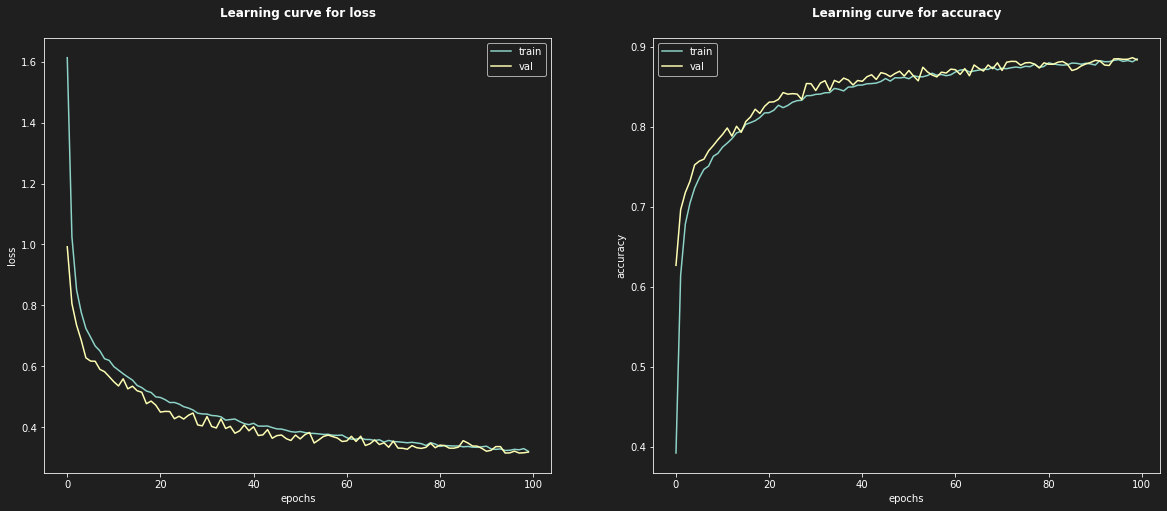

In [15]:
plot_lc(cnn.history.history)

In [17]:
y_pred = np.argmax(cnn.predict(X_test), axis=1)

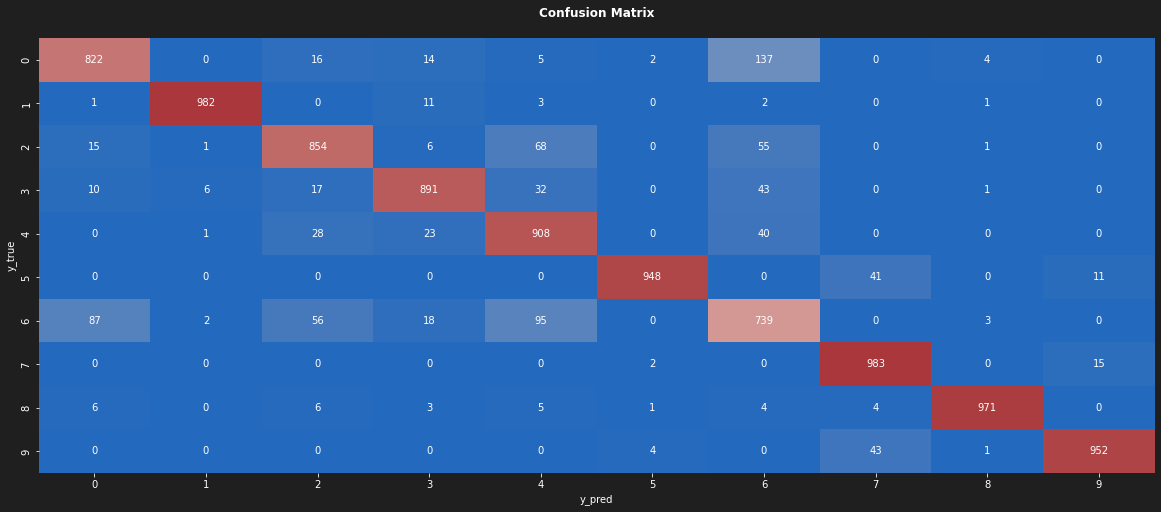

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1000
           1       0.99      0.98      0.99      1000
           2       0.87      0.85      0.86      1000
           3       0.92      0.89      0.91      1000
           4       0.81      0.91      0.86      1000
           5       0.99      0.95      0.97      1000
           6       0.72      0.74      0.73      1000
           7       0.92      0.98      0.95      1000
           8       0.99      0.97      0.98      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.90      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [18]:
plot_cm(y_test, y_pred)
print(classification_report(y_test, y_pred))

# Visualiser random transformation

<br>

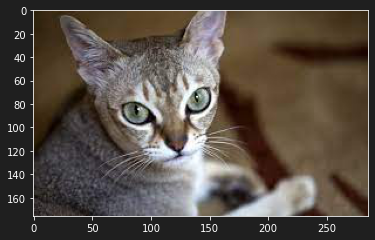

In [25]:
chat = plt.imread('chat.jpg')
plt.imshow(chat)
plt.show()

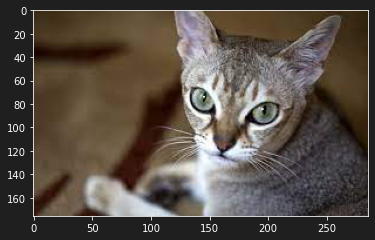

In [39]:
plt.imshow(keras.ops.flip(chat, axis=1))

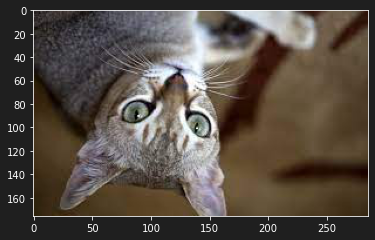

In [41]:
plt.imshow(keras.ops.flip(chat, axis=0))

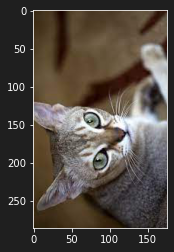

In [54]:
plt.imshow(keras.ops.rot90(chat))